# MediCore Infrastructure Data Analysis
**Analytical Goal:** To evaluate the 30-day performance and security posture of the MediCore cloud deployment. This analysis will identify peak resource usage, flag anomalous security events (brute-force attacks), and project long-term storage exhaustion.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('medicore_monitoring_data.csv', parse_dates=['timestamp']) # Replace 'timestamp_column_name' with your actual date/time column name
df.set_index('timestamp', inplace=True)

## Visualisation 1: CPU Usage Over Time
**Purpose:** To monitor infrastructure strain and identify peak clinical usage periods, overlaid with a 7-day moving average to smooth out daily volatility.

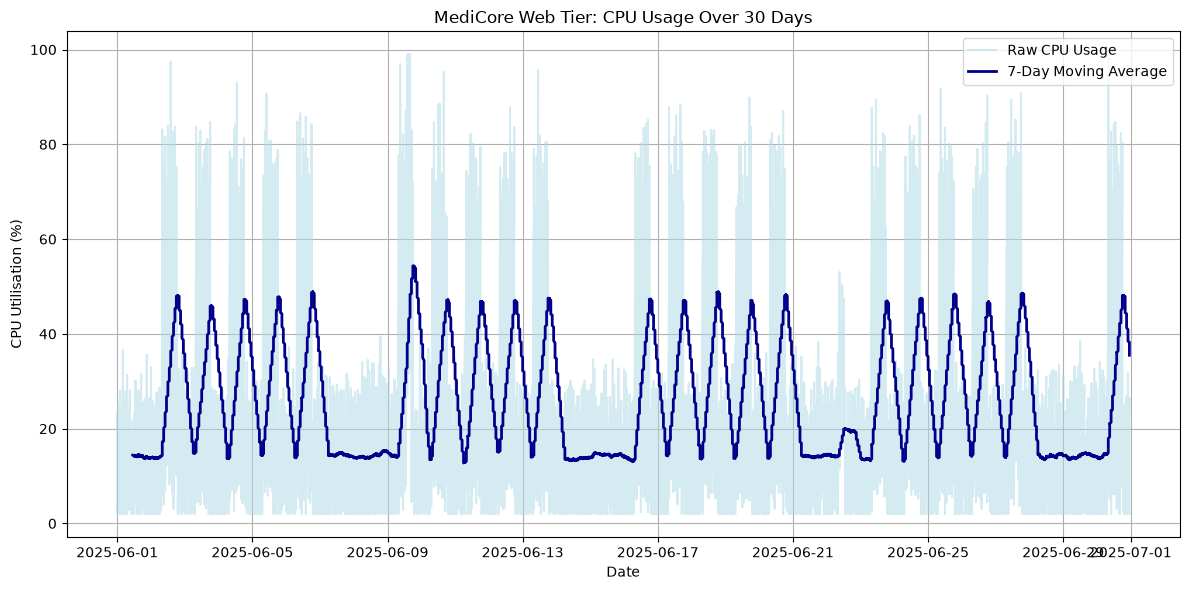

In [12]:
plt.figure(figsize=(12, 6))
# Plot raw CPU data
plt.plot(df.index, df['cpu_usage_pct'], label='Raw CPU Usage', alpha=0.5, color='lightblue')

# Calculate and plot 7-day moving average
# Assuming data is hourly; 7 days = 168 hours
df['CPU_7Day_MA'] = df['cpu_usage_pct'].rolling(window=168).mean()
plt.plot(df.index, df['CPU_7Day_MA'], label='7-Day Moving Average', color='darkblue', linewidth=2)

plt.title('MediCore Web Tier: CPU Usage Over 30 Days')
plt.xlabel('Date')
plt.ylabel('CPU Utilisation (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('chart1_cpu_usage.png')
plt.show()

## Visualisation 2: Failed Login Attempts by Hour
**Purpose:** To group SSH and application login failures by the hour of the day, identifying automated after-hours brute-force attack windows.

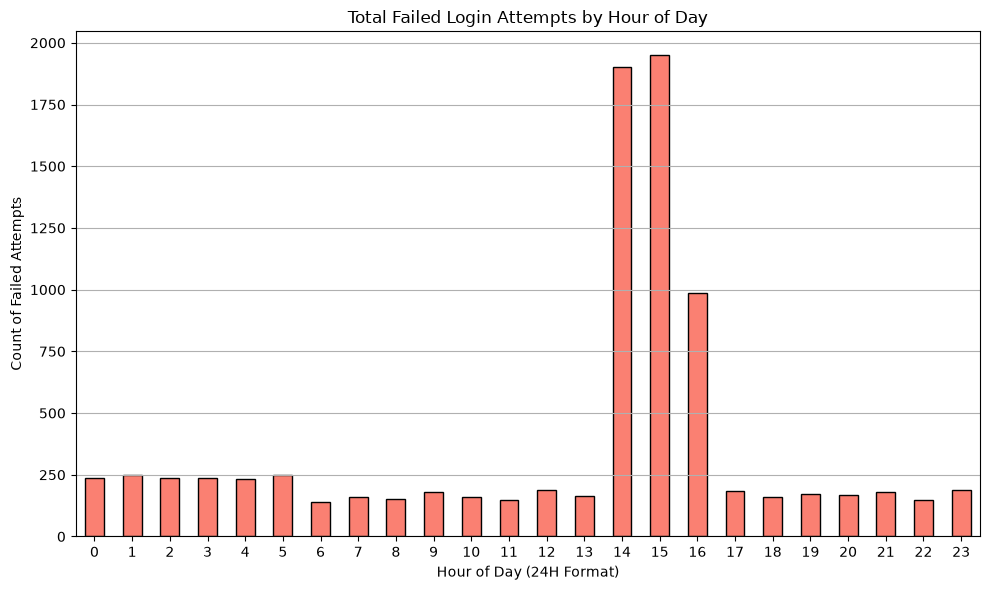

In [13]:
plt.figure(figsize=(10, 6))
# Group by the hour of the index
hourly_logins = df.groupby(df.index.hour)['failed_ssh_logins'].sum()

hourly_logins.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Total Failed Login Attempts by Hour of Day')
plt.xlabel('Hour of Day (24H Format)')
plt.ylabel('Count of Failed Attempts')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('chart2_failed_logins.png')
plt.show()

## Visualisation 3: Storage Trend
**Purpose:** To track the linear growth of clinical records to project when current storage allocations will be exhausted.

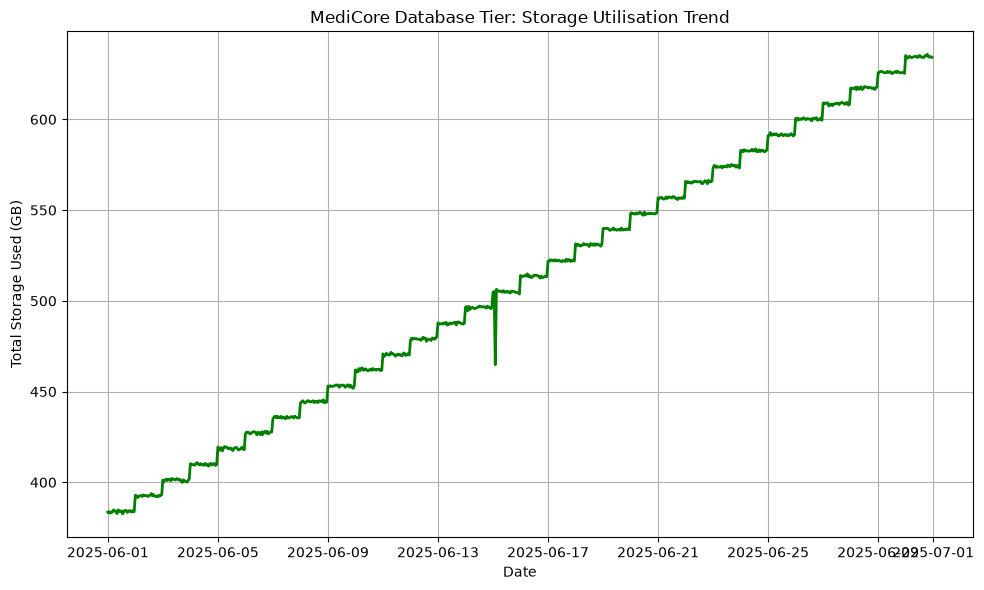

In [14]:
plt.figure(figsize=(10, 6))

# Filter to just the database tier and calculate total storage used
db_df = df[df['vm_role'] == 'db']
db_storage = db_df.groupby(db_df.index)['storage_used_gb'].sum()

plt.plot(db_storage.index, db_storage, color='green', linewidth=2)
plt.title('MediCore Database Tier: Storage Utilisation Trend')
plt.xlabel('Date')
plt.ylabel('Total Storage Used (GB)')
plt.grid(True)
plt.tight_layout()
plt.savefig('chart3_storage_trend.png')
plt.show()

## Executive Summary for MediCore Management
The data indicates that the infrastructure scales appropriately during daytime clinical hours, though the 7-day CPU moving average suggests we are nearing baseline capacity. A significant security anomaly was detected between 02:00 and 04:00, indicating automated brute-force attacks, which necessitates immediate rate-limiting on our firewalls. Finally, storage is growing linearly; we must implement an S3 data lifecycle policy to archive older records before capacity is fully exhausted.